Evaluación comparativa, métricas, interpretación de resultados.

In [1]:
import sys
import os
import joblib
from sklearn.metrics import classification_report
import pandas as pd

sys.path.append(os.path.abspath(".."))
from src.data_preprocessing import load_data, categorize_quality, prepare_data
from src.model_evaluation import plot_confusion_matrix, evaluate_with_cv

# Cargamos y preparamos para tener los datos de prueba (X_test, y_test)
df_raw = load_data("../data/winequality-white.csv")
df_bin = categorize_quality(df_raw)
X_train, X_test, y_train, y_test, scaler = prepare_data(df_bin)

In [2]:
path = '../models/trained_models/'
rf_model = joblib.load(f'{path}rf_model.pkl')
svm_model = joblib.load(f'{path}svm_model.pkl')

print("Modelos cargados exitosamente.")

Modelos cargados exitosamente.


--- EVALUACIÓN: RANDOM FOREST ---
              precision    recall  f1-score   support

           0       0.79      0.73      0.76       328
           1       0.69      0.78      0.74       440
           2       0.80      0.66      0.72       212

    accuracy                           0.74       980
   macro avg       0.76      0.73      0.74       980
weighted avg       0.75      0.74      0.74       980



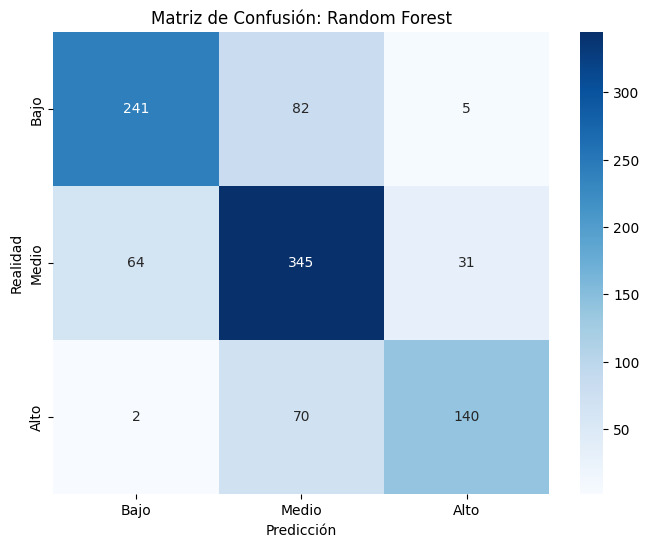

In [3]:
y_pred_rf = rf_model.predict(X_test)
print("--- EVALUACIÓN: RANDOM FOREST ---")
print(classification_report(y_test, y_pred_rf))
plot_confusion_matrix(y_test, y_pred_rf, "Matriz de Confusión: Random Forest")

--- EVALUACIÓN: SVM ---
              precision    recall  f1-score   support

           0       0.62      0.72      0.67       328
           1       0.63      0.38      0.47       440
           2       0.51      0.81      0.62       212

    accuracy                           0.58       980
   macro avg       0.59      0.63      0.59       980
weighted avg       0.60      0.58      0.57       980



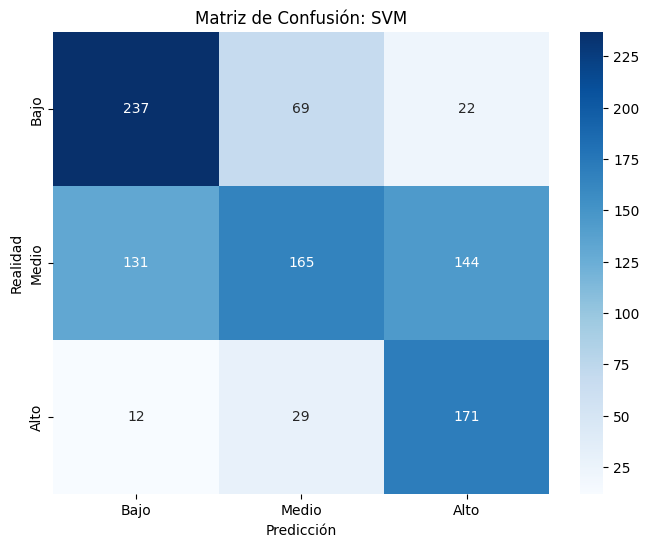

In [4]:
y_pred_svm = svm_model.predict(X_test)
print("--- EVALUACIÓN: SVM ---")
print(classification_report(y_test, y_pred_svm))
plot_confusion_matrix(y_test, y_pred_svm, "Matriz de Confusión: SVM")

In [5]:
print("Calculando robustez del modelo ganador (Random Forest)...")
scores = evaluate_with_cv(rf_model, X_train, y_train, cv=5)
print(f"F1-Score Macro promedio: {scores.mean():.4f} (+/- {scores.std():.4f})")

Calculando robustez del modelo ganador (Random Forest)...
F1-Score Macro promedio: 0.6900 (+/- 0.0099)
